# Imports

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','no-latex'])
from pathlib import Path

In [35]:
seed = 69
rng = np.random.default_rng(seed)
FIG_DIR = Path("/Users/michelefanelli/Documents/Thesis/Latex/Figures")
FIG_DIR.mkdir(exist_ok=True)

## Load & prepare the S&P 500 price panel

Keep only stocks that already existed on the first date; the residual `NaN`s that
remain are the *real* missingness the thesis imputes.

In [4]:

CSV = Path("../Data/sp500_prices.csv")

prices = pd.read_csv(CSV, index_col="Date", parse_dates=["Date"]).sort_index()

# Eliminate stocks that did not exist at the start date (NaN on the first day)
prices = prices.loc[:, prices.iloc[0].notna()]

# Daily simple returns -- the panel the imputation / portfolio analysis runs on
returns = prices.pct_change().iloc[1:]

print(f"{prices.shape[1]} stocks survive from {prices.index[0].date()} "
      f"to {prices.index[-1].date()}  ({len(prices)} trading days)")
print(f"residual missingness (real gaps to impute): "
      f"{returns.isna().mean().mean():.2%}")
prices.iloc[:3, :5]

422 stocks survive from 2010-01-04 to 2026-05-29  (4126 trading days)
residual missingness (real gaps to impute): 0.00%


,A,AAPL,ABT,ACGL,ACN
Date,,,,,
2010-01-04,19.810984,6.406480,18.207747,7.601905,31.227354
2010-01-05,19.595781,6.417557,18.060642,7.576549,31.420353
2010-01-06,19.526159,6.315477,18.160942,7.543795,31.754366


## Choose 50 stocks

Choose a smaller, nimbler sample of stocks stratified across sectors

In [5]:
tickers_50 = [
    # Information Technology
    "AAPL", "MSFT", "ORCL", "CSCO", "IBM", "INTC", "TXN",
    # Financials
    "JPM", "BAC", "WFC", "GS", "MS", "AXP",
    # Communication Services
    "GOOGL", "DIS", "CMCSA", "VZ",
    # Consumer Discretionary
    "AMZN", "HD", "MCD", "NKE", "LOW",
    # Health Care
    "JNJ", "MRK", "PFE", "UNH", "ABT", "AMGN",
    # Industrials
    "CAT", "HON", "UPS", "UNP", "LMT", "MMM",
    # Consumer Staples
    "PG", "KO", "PEP", "WMT", "COST",
    # Energy
    "XOM", "CVX", "COP", "SLB",
    # Utilities
    "NEE", "DUK", "SO",
    # Materials
    "SHW", "APD",
    # Real Estate
    "AMT", "PLD"
]

sample = prices[tickers_50]
log_sample = np.log(sample)
log_returns = log_sample.diff().iloc[1:]

## Inject realistic missingness

Three independently tunable styles applied to the dense panel:

- **Sparse** isolated entries — one asset missing at scattered dates (`add_sparse`, `rate`).
- **Contiguous gaps** — an asset missing for many consecutive periods (`add_gaps`, `n`, `mean_len`).
- **Whole missing rows** — a date with no observations: holidays, calendar mismatch, DB outages (`add_missing_rows`, `rate`).

Because the base panel is dense, `mask = miss.isna()` is exactly the set of hidden cells — the evaluation mask to score imputation against.

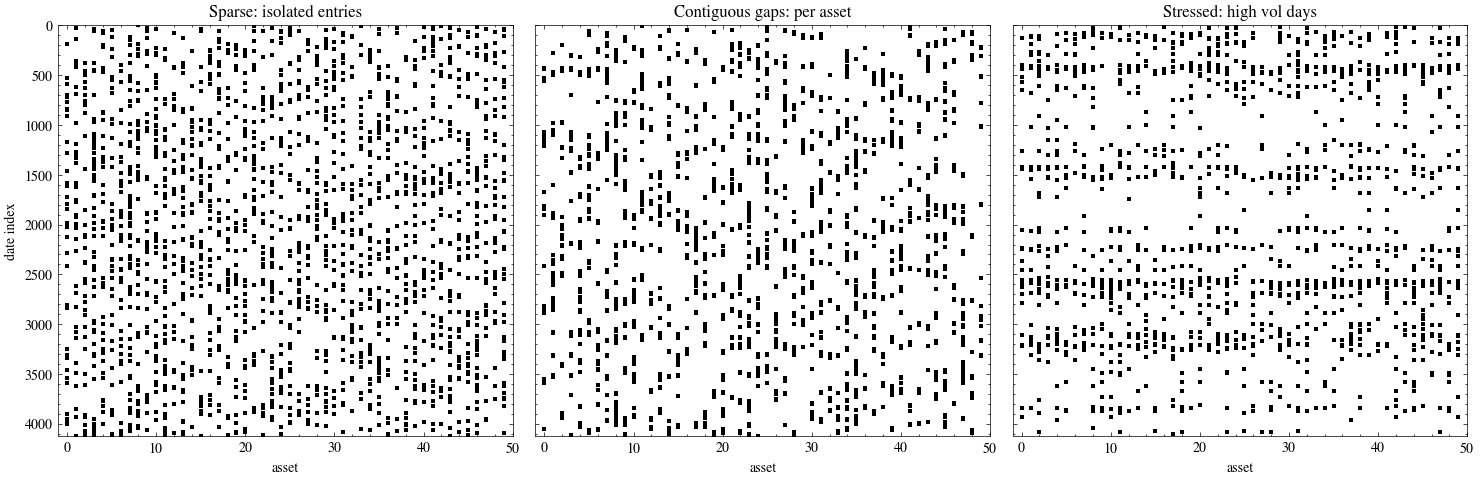

In [36]:
def add_sparse(df, rate=0.02):        # isolated entries: one asset at scattered dates
    return df.mask(rng.random(df.shape) < rate)

def add_gaps(df, n=25, mean_len=15):  # contiguous gaps: long runs per asset
    X = df.copy(); T, N = X.shape
    for _ in range(n):
        j, t0 = rng.integers(N), rng.integers(T)
        X.iloc[t0:t0 + max(1, int(rng.exponential(mean_len))), j] = np.nan
    return X

def stress_mask(
    X: pd.DataFrame,
    base_q: float = 0.05,
    stress_q: float = 0.25,
    stress_quantile: float = 0.90,
    seed: int = 3
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    X = np.log(X).diff().iloc[1:]  # log returns

    market_proxy = X.mean(axis=1)

    stress_score = market_proxy ** 2

    threshold = stress_score.quantile(stress_quantile)
    stress_days = stress_score >= threshold

    probs = pd.Series(float(base_q), index=X.index)
    probs.loc[stress_days] = stress_q

    random_matrix = rng.random(X.shape)
    prob_matrix = np.repeat(probs.values[:, None], X.shape[1], axis=1)

    mask = random_matrix < prob_matrix
    return pd.DataFrame(mask, index=X.index, columns=X.columns)

ex = sample
examples = {
    "Sparse: isolated entries":    add_sparse(ex, rate=0.01).isna(),
    "Contiguous gaps: per asset":  add_gaps(ex, n=1000, mean_len=20).isna(),
    "Stressed: high vol days":   stress_mask(ex, base_q=0, stress_q=0.07, stress_quantile=0.90, seed=3),
}

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)
for ax, (title, m) in zip(axes, examples.items()):
    ys, xs = np.nonzero(m.to_numpy())                  # markers, not pixels
    ax.scatter(xs, ys, s=5, marker="s", c="k", linewidths=0)
    ax.set(xlim=(-1, m.shape[1]), ylim=(m.shape[0], -1), xlabel="asset",
           title=f"{title}")
axes[0].set_ylabel("date index")
plt.tight_layout()
plt.savefig(FIG_DIR / "missingness_examples.pdf", bbox_inches="tight")
plt.show()


In [21]:
test = add_sparse(sample, rate=0.05).isna()
test.head()

,AAPL,MSFT,ORCL,CSCO,IBM,INTC,TXN,JPM,BAC,WFC,...,CVX,COP,SLB,NEE,DUK,SO,SHW,APD,AMT,PLD
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2010-01-05,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2010-01-06,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
2010-01-07,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2010-01-08,False,False,False,False,False,True,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False


In [29]:
test_ = sample[~test]
test_.head()

,AAPL,MSFT,ORCL,CSCO,IBM,INTC,TXN,JPM,BAC,WFC,...,CVX,COP,SLB,NEE,DUK,SO,SHW,APD,AMT,PLD
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.406480,23.027512,19.947363,15.889596,71.938843,13.519426,16.938730,28.279205,12.038233,17.835871,...,40.890915,22.623255,45.290916,8.230570,24.938585,NaN,17.168999,51.112740,31.462639,15.292116
2010-01-05,6.417557,23.034946,19.923283,NaN,71.069832,13.512950,16.841049,28.826973,12.429533,18.325504,...,41.180576,22.644772,45.419128,8.150194,24.527103,15.922311,16.762531,50.688667,31.983877,15.515140
2010-01-06,6.315477,22.893581,19.634310,15.715837,70.608147,13.467627,16.717304,28.985348,12.575310,18.351620,...,41.185722,22.808270,NaN,8.230570,24.615278,NaN,16.542591,50.270718,32.150387,NaN
2010-01-07,6.303802,22.655495,19.570086,15.786625,70.363754,13.338132,16.769413,29.559530,12.989633,19.017529,...,41.030560,22.717916,46.910603,8.207385,24.732847,16.078703,16.690142,49.981823,32.063519,15.503082
2010-01-08,6.345711,22.811741,19.810904,15.870293,71.069832,NaN,17.153639,NaN,12.874538,18.841259,...,41.102982,22.915850,47.679958,NaN,24.747536,16.044489,16.832129,50.301445,NaN,15.460893


In [30]:
test_ = np.log(test_).diff().iloc[1:]
test_

,AAPL,MSFT,ORCL,CSCO,IBM,INTC,TXN,JPM,BAC,WFC,...,CVX,COP,SLB,NEE,DUK,SO,SHW,APD,AMT,PLD
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,0.001728,0.000323,-0.001208,NaN,-0.012153,-0.000479,-0.005783,0.019185,0.031988,0.027082,...,0.007059,0.000951,0.002827,-0.009814,-0.016637,NaN,-0.023959,-0.008331,0.016431,0.014479
2010-01-06,-0.016034,-0.006156,-0.014610,NaN,-0.006517,-0.003360,-0.007375,0.005479,0.011660,0.001424,...,0.000125,0.007194,NaN,0.009814,0.003589,NaN,-0.013208,-0.008280,0.005193,NaN
2010-01-07,-0.001850,-0.010454,-0.003276,0.004494,-0.003467,-0.009662,0.003112,0.019616,0.032416,0.035643,...,-0.003775,-0.003969,NaN,-0.002821,0.004765,NaN,0.008880,-0.005763,-0.002706,NaN
2010-01-08,0.006626,0.006873,0.012230,0.005286,0.009985,NaN,0.022654,NaN,-0.008900,-0.009312,...,0.001764,0.008675,0.016267,NaN,0.000594,-0.002130,0.008471,0.006374,NaN,-0.002725
2010-01-11,-0.008860,-0.012802,0.000405,-0.002843,-0.010525,NaN,NaN,NaN,0.008900,-0.002082,...,0.017587,0.005803,0.000000,NaN,0.010044,0.013012,-0.013823,0.018162,NaN,0.001169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-22,0.012480,-0.001242,0.012099,0.018525,0.003433,0.011245,0.035619,0.011093,0.006002,0.006303,...,0.002196,-0.000747,0.000524,-0.012792,0.008069,0.003284,0.001749,-0.002484,0.000381,NaN
2026-05-26,-0.001588,-0.006087,0.005089,-0.017425,NaN,0.030246,0.049466,0.001174,0.007692,NaN,...,-0.035735,-0.032826,0.012147,-0.010216,-0.005586,-0.004877,0.006996,0.000449,0.005965,0.007103
2026-05-27,0.008140,-0.008109,-0.010937,0.011261,NaN,-0.014269,-0.023166,-0.024621,-0.021298,NaN,...,NaN,-0.012430,-0.025858,0.000000,NaN,-0.003727,-0.004121,-0.013453,0.000162,-0.002862


In [32]:
log_returns.to_csv("../Data/log_returns.csv")

In [24]:
test_.to_csv("../Data/test.csv")